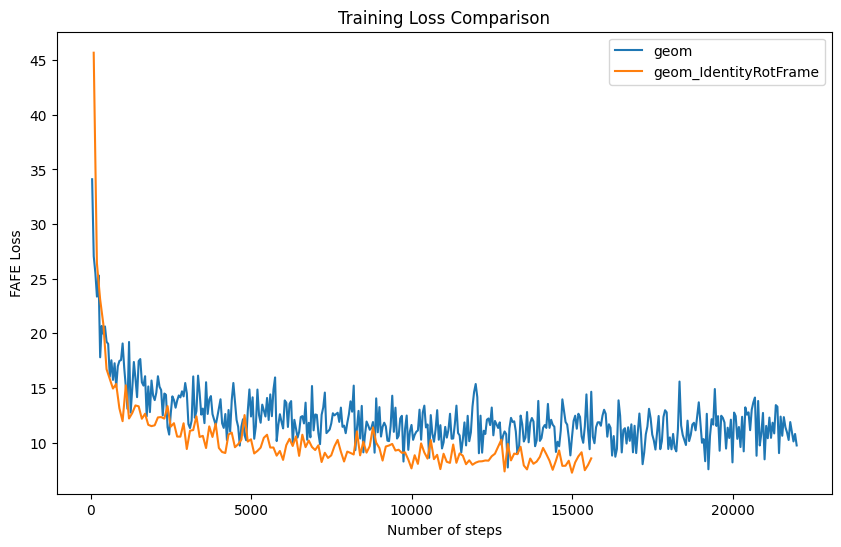

In [15]:
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt
from pathlib import Path

# Path to your event file
run_to_event_dir = {
    "geom": "/datastor1/dy4652/proteinzen/outputs/geom/train/lightning_logs/version_1",
    "geom_IdentityRotFrame": "/datastor1/dy4652/proteinzen/outputs/geom_identityRot_frame/train/lightning_logs/version_0",
}

plt.figure(figsize=(10, 6))

for run, event_dir in run_to_event_dir.items():
    # Load scalars
    event_path = str(list(Path(event_dir).glob("*.tfevents.*"))[0])
    ea = event_accumulator.EventAccumulator(event_path)
    ea.Reload()

    # List all scalar tags recorded
    # print(ea.Tags()["scalars"])

    loss_events = ea.Scalars("train/fafe_step")

    steps = [e.step for e in loss_events]
    if run == 'geom_IdentityRotFrame':
        steps = [e.step * 2 for e in loss_events]
    values = [e.value for e in loss_events]

    plt.plot(steps, values, label=run)

plt.xlabel("Number of steps")
plt.ylabel("FAFE Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()